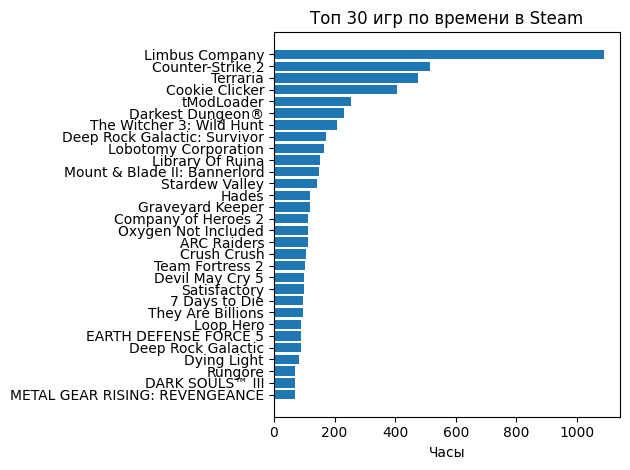

In [1]:
import os
import json

import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

steamApiKey = os.getenv("STEAM_API_KEY")
startingSteamId =  os.getenv("STEAM_ID")

if not steamApiKey:
    print("API ключ не найден")
    exit()
elif not startingSteamId:
    print("STEAM_ID не найден")
    exit()

url = f"http://api.steampowered.com/IPlayerService/GetOwnedGames/v0001/"

params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "include_appinfo": True,
    "include_played_free_games": True,
    "format": "json"
}

response = requests.get(url, params=params)
data = response.json()

if "games" not in data["response"]:
    print("Нет доступа к играм (возможно, профиль приватный)")
    exit()

games = data["response"]["games"]

# Сортируем по времени игры (в минутах)
gamesSorted = sorted(games, key=lambda x: x["playtime_forever"], reverse=True)

topGames = gamesSorted[:30]

names = [game["name"] for game in topGames]
playtime = [game["playtime_forever"] / 60 for game in topGames]

plt.figure()
plt.barh(names[::-1], playtime[::-1])
plt.xlabel("Часы")
plt.title("Топ 30 игр по времени в Steam")
plt.tight_layout()

plt.show()

In [2]:
# === GetOwnedGames ===
url = "http://api.steampowered.com/IPlayerService/GetOwnedGames/v0001/"
params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "include_appinfo": True,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open("../data/steamUserData.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print("Датасет сохранён в ../data/steamUserData.json")

Датасет сохранён в ../data/steamUserData.json


In [3]:
# === GetRecentlyPlayedGames ===
url = "http://api.steampowered.com/IPlayerService/GetRecentlyPlayedGames/v0001/"
params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "include_appinfo": True,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open("../data/steamRecentlyPlayedGames.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print("Датасет сохранён в ../data/steamRecentlyPlayedGames.json")


Датасет сохранён в ../data/steamRecentlyPlayedGames.json


In [4]:
# === GetFriendList ===
url = "http://api.steampowered.com/ISteamUser/GetFriendList/v0001/"
params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "relationship": "friend",
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open("../data/steamFriendList.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print("Датасет сохранён в ../data/steamFriendList.json")

Датасет сохранён в ../data/steamFriendList.json


In [5]:
# === GetPlayerSummaries ===
url = "http://api.steampowered.com/ISteamUser/GetPlayerSummaries/v0002/"
params = {
    "key": steamApiKey,
    "steamids": startingSteamId,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open("../data/steamPlayerSummaries.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print("Датасет сохранён в ../data/steamPlayerSummaries.json")

Датасет сохранён в ../data/steamPlayerSummaries.json


In [6]:
# === GetPlayerBans ===
url = "http://api.steampowered.com/ISteamUser/GetPlayerBans/v0001/"
params = {
    "key": steamApiKey,
    "steamids": startingSteamId,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open("../data/steamPlayerBans.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print("Датасет сохранён в ../data/steamPlayerBans.json")

Датасет сохранён в ../data/steamPlayerBans.json


In [7]:
# === GetPlayerAchievements (пример для Hades — appid 1145360) ===
appIdForAchievements = 1145360
url = "http://api.steampowered.com/ISteamUserStats/GetPlayerAchievements/v0001/"
params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "appid": appIdForAchievements,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open(f"../data/steamPlayerAchievements_{appIdForAchievements}.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print(f"Датасет сохранён в ../data/steamPlayerAchievements_{appIdForAchievements}.json")

Датасет сохранён в ../data/steamPlayerAchievements_1145360.json


In [8]:
# === GetUserStatsForGame (тот же Hades) ===
appIdForStats = 1145360
url = "http://api.steampowered.com/ISteamUserStats/GetUserStatsForGame/v0002/"
params = {
    "key": steamApiKey,
    "steamid": startingSteamId,
    "appid": appIdForStats,
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open(f"../data/steamUserStatsForGame_{appIdForStats}.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print(f"Датасет сохранён в ../data/steamUserStatsForGame_{appIdForStats}.json")

Датасет сохранён в ../data/steamUserStatsForGame_1145360.json


In [9]:
# === Данные страницы игры (официальный Steam Store API) ===
appIdForGame = 1145360
url = f"https://store.steampowered.com/api/appdetails/"
params = {
    "appids": appIdForGame,
    "cc": "RU",           # страна для цен
    "l": "russian",       # язык
    "format": "json"
}
response = requests.get(url, params=params)
data = response.json()

with open(f"../data/steamGameData_{appIdForGame}.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print(f"Датасет сохранён в ../data/steamGameData_{appIdForGame}.json")

Датасет сохранён в ../data/steamGameData_1145360.json


In [10]:
# === SteamSpy API (может возвращать теги) ===
appIdForGame = 1145360
url = "https://steamspy.com/api.php"
params = {
    "request": "appdetails",
    "appid": appIdForGame
}
response = requests.get(url, params=params)
data = response.json()

with open(f"../data/SteamSpyAPI_{appIdForGame}.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print(f"Датасет сохранён в ../data/SteamSpyAPI_{appIdForGame}.json")

Датасет сохранён в ../data/SteamSpyAPI_1145360.json


In [11]:
# === Статистика отзывов (прямо со страницы Steam) ===
appIdForGame = 1145360
url = f"https://store.steampowered.com/appreviews/{appIdForGame}"
params = {
    "json": 1,
    "language": "all",
    "num_per_page": 0
}
response = requests.get(url, params=params)
data = response.json()

with open(f"../data/SteamGameReviews_{appIdForGame}.json", "w", encoding="utf-8") as file:
    json.dump(data, file, ensure_ascii=False, indent=2)
print(f"Датасет сохранён в ../data/SteamGameReviews_{appIdForGame}.json")

Датасет сохранён в ../data/SteamGameReviews_1145360.json
